In [ ]:
%pip install meteostat

**Hypothesis Test 2 - Data Merging - EDA**

---



In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
import meteostat as ms
import matplotlib.pyplot as plt

In [ ]:
result_data = pd.read_csv('/content/drive/MyDrive/DSA210/F1 - Race Dataset/results.csv')
races_data = pd.read_csv('/content/drive/MyDrive/DSA210/F1 - Race Dataset/races.csv')

race_merged = pd.merge(races_data, result_data, on='raceId', how='inner')
col = ['fp1_date', 'fp1_time', 'fp2_date', 'fp2_time', 'fp3_date', 'fp3_time', 'quali_date', 'quali_time', 'sprint_date', 'sprint_time', 'url', 'milliseconds', 'number', 'fastestLapSpeed', 'points', 'position', 'positionText', 'fastestLap', 'time_y','fastestLapTime', 'grid', 'date', 'time_x', 'resultId']
race_updated = race_merged.drop(columns=col)
race_updated.head(10)

,raceId,year,round,circuitId,name,driverId,constructorId,positionOrder,laps,rank,statusId
0,1166,2025,22,80,Las Vegas Grand Prix,830,9,1,50,1,1
1,1166,2025,22,80,Las Vegas Grand Prix,847,131,2,50,9,1
2,1166,2025,22,80,Las Vegas Grand Prix,863,131,3,50,2,1
3,1166,2025,22,80,Las Vegas Grand Prix,844,6,4,50,3,1
4,1166,2025,22,80,Las Vegas Grand Prix,832,3,5,50,4,1
5,1166,2025,22,80,Las Vegas Grand Prix,865,215,6,50,10,1
6,1166,2025,22,80,Las Vegas Grand Prix,807,15,7,50,8,1
7,1166,2025,22,80,Las Vegas Grand Prix,1,6,8,50,6,1
8,1166,2025,22,80,Las Vegas Grand Prix,839,210,9,50,7,1
9,1166,2025,22,80,Las Vegas Grand Prix,860,210,10,50,5,1


In [ ]:
final = race_updated[race_updated['year'] >= 2010]
final.head(10)

,raceId,year,round,circuitId,name,driverId,constructorId,positionOrder,laps,rank,statusId
0,1166,2025,22,80,Las Vegas Grand Prix,830,9,1,50,1,1
1,1166,2025,22,80,Las Vegas Grand Prix,847,131,2,50,9,1
2,1166,2025,22,80,Las Vegas Grand Prix,863,131,3,50,2,1
3,1166,2025,22,80,Las Vegas Grand Prix,844,6,4,50,3,1
4,1166,2025,22,80,Las Vegas Grand Prix,832,3,5,50,4,1
5,1166,2025,22,80,Las Vegas Grand Prix,865,215,6,50,10,1
6,1166,2025,22,80,Las Vegas Grand Prix,807,15,7,50,8,1
7,1166,2025,22,80,Las Vegas Grand Prix,1,6,8,50,6,1
8,1166,2025,22,80,Las Vegas Grand Prix,839,210,9,50,7,1
9,1166,2025,22,80,Las Vegas Grand Prix,860,210,10,50,5,1


In [ ]:
pitstop_data = pd.read_csv('/content/drive/MyDrive/DSA210/F1 - Race Dataset/pit_stops.csv')
pitstop_data.head(40)

,raceId,driverId,stop,lap,time,duration,milliseconds
0,258,100,1,1,14:01:34,49.111,49111
1,258,79,1,17,14:20:46,28.482,28482
2,258,57,1,18,14:22:35,43.745,43745
3,258,71,1,18,14:23:00,21.992,21992
4,258,105,1,19,14:24:39,27.693,27693
5,258,91,1,19,14:24:41,24.806,24806
6,258,44,1,18,14:25:13,53.89,53890
7,258,94,1,22,14:28:34,34.437,34437
8,258,30,1,23,14:28:40,23.342,23342
9,258,104,1,23,14:29:00,56.753,56753


In [ ]:
pitstop_data.drop(columns=['time'], inplace=True)
pitstop_data.head(40)

,raceId,driverId,stop,lap,duration,milliseconds
0,258,100,1,1,49.111,49111
1,258,79,1,17,28.482,28482
2,258,57,1,18,43.745,43745
3,258,71,1,18,21.992,21992
4,258,105,1,19,27.693,27693
5,258,91,1,19,24.806,24806
6,258,44,1,18,53.89,53890
7,258,94,1,22,34.437,34437
8,258,30,1,23,23.342,23342
9,258,104,1,23,56.753,56753


In [ ]:
hyp1 = pd.merge(final, pitstop_data, on=['raceId', 'driverId'], how='inner')
hyp1.head(10)

,raceId,year,round,circuitId,name,driverId,constructorId,positionOrder,laps,rank,statusId,stop,lap,duration,milliseconds
0,1166,2025,22,80,Las Vegas Grand Prix,830,9,1,50,1,1,1,25,21.708,21708
1,1166,2025,22,80,Las Vegas Grand Prix,847,131,2,50,9,1,1,17,20.929,20929
2,1166,2025,22,80,Las Vegas Grand Prix,863,131,3,50,2,1,1,2,21.968,21968
3,1166,2025,22,80,Las Vegas Grand Prix,844,6,4,50,3,1,1,24,21.351,21351
4,1166,2025,22,80,Las Vegas Grand Prix,832,3,5,50,4,1,1,22,21.164,21164
5,1166,2025,22,80,Las Vegas Grand Prix,865,215,6,50,10,1,1,20,21.324,21324
6,1166,2025,22,80,Las Vegas Grand Prix,807,15,7,50,8,1,1,30,22.333,22333
7,1166,2025,22,80,Las Vegas Grand Prix,1,6,8,50,6,1,1,29,21.638,21638
8,1166,2025,22,80,Las Vegas Grand Prix,839,210,9,50,7,1,1,27,22.389,22389
9,1166,2025,22,80,Las Vegas Grand Prix,860,210,10,50,5,1,1,17,21.491,21491


In [ ]:
print((hyp1['milliseconds'] == r'\N').any())

False


In [ ]:
print((hyp1['milliseconds'] == '0').any())

False


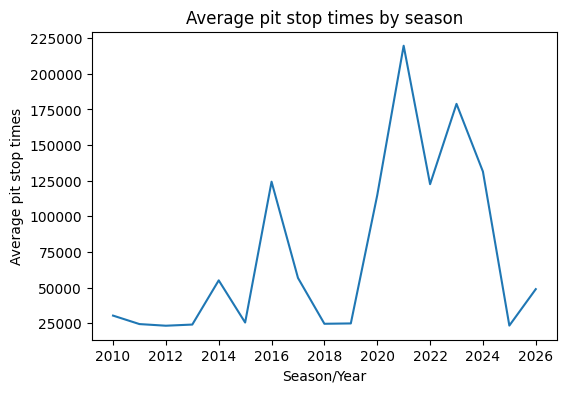

In [ ]:
hyp1['milliseconds'] = pd.to_timedelta(hyp1['milliseconds'])
avg_pit_stop_times = (hyp1.dropna(subset=['year', 'milliseconds']).groupby('year')['milliseconds'].mean().sort_index())
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(avg_pit_stop_times.index.astype(int), avg_pit_stop_times.values)
ax.set_xlabel('Season/Year')
ax.set_ylabel('Average pit stop times')
ax.set_title('Average pit stop times by season')
plt.show()

In [ ]:
hyp1['lap'] = hyp1['lap'].astype(int)
avg_pit_stop_each_race = (hyp1.dropna(subset=['name', 'lap']).groupby('name')['lap'].mean().sort_index())
avg_pit_stop_each_race

name
70th Anniversary Grand Prix    24.024390
Abu Dhabi Grand Prix           23.593939
Australian Grand Prix          22.797153
Austrian Grand Prix            29.691796
Azerbaijan Grand Prix          23.714801
Bahrain Grand Prix             23.746479
Belgian Grand Prix             18.344948
Brazilian Grand Prix           28.416342
British Grand Prix             22.478485
Canadian Grand Prix            33.426025
Chinese Grand Prix             20.822294
Dutch Grand Prix               38.007463
Eifel Grand Prix               27.878788
Emilia Romagna Grand Prix      27.468571
European Grand Prix            22.357955
French Grand Prix              23.255556
German Grand Prix              29.196262
Hungarian Grand Prix           28.833564
Indian Grand Prix              26.344538
Italian Grand Prix             24.769767
Japanese Grand Prix            20.138614
Korean Grand Prix              22.832335
Las Vegas Grand Prix           19.311828
Malaysian Grand Prix           23.158690
Mexican Gra

Text(0, 0.5, 'Pit Stop Laps')

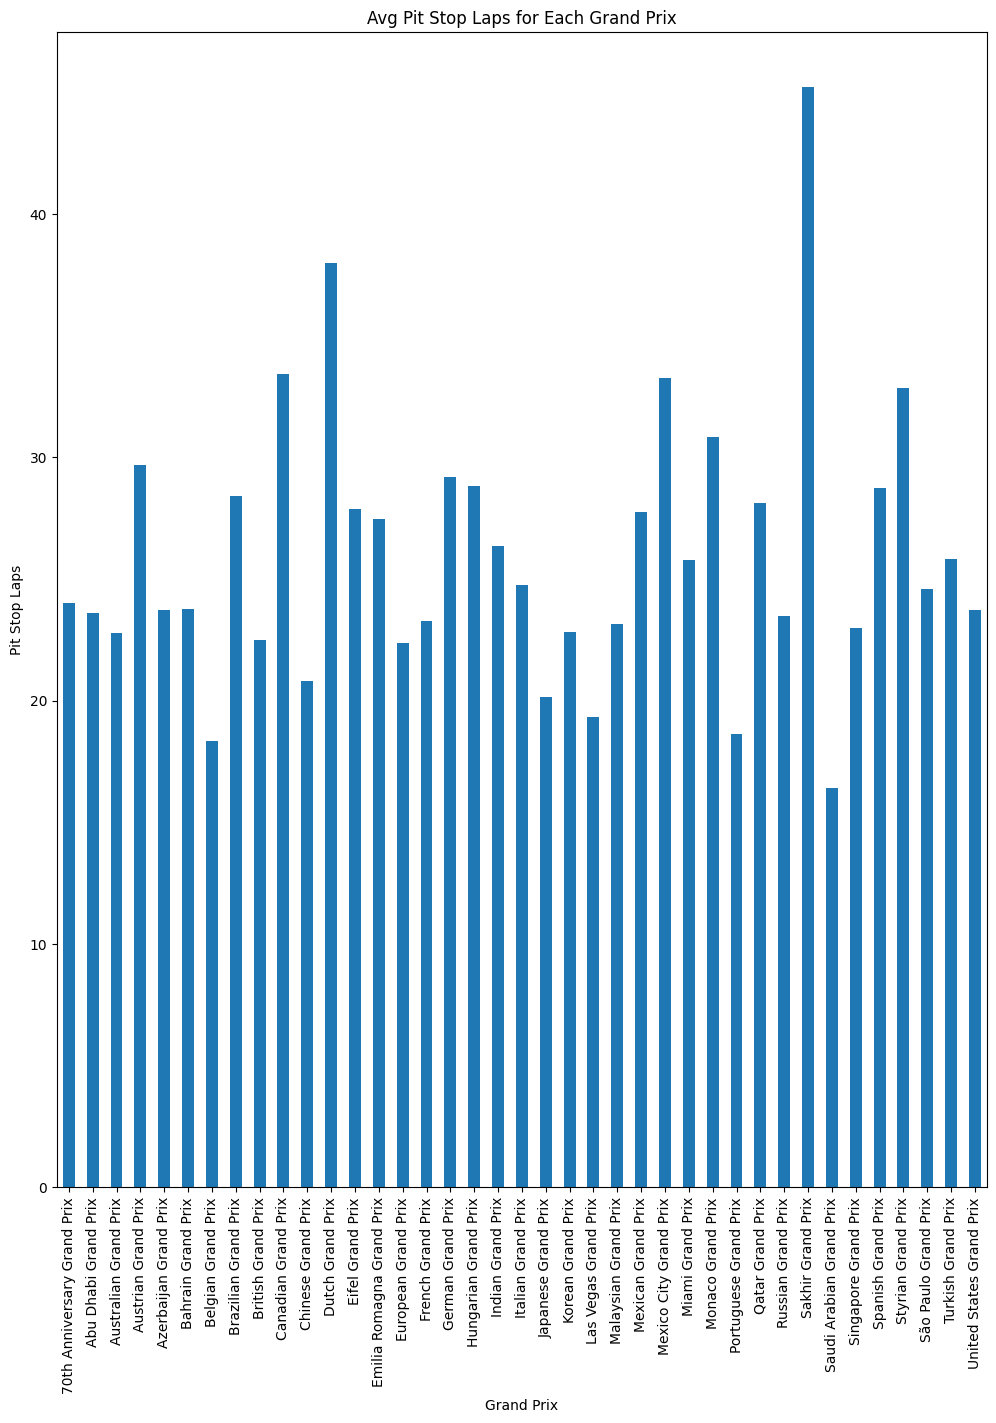

In [ ]:
fig, ax = plt.subplots(figsize=(12, 15))
avg_pit_stop_each_race.plot(kind='bar', ax=ax)
ax.set_title('Avg Pit Stop Laps for Each Grand Prix')
ax.set_xlabel('Grand Prix')
ax.set_ylabel('Pit Stop Laps')

In [ ]:
monaco = hyp1.loc[hyp1['name'] == "Monaco Grand Prix"]
monaco = (monaco.dropna(subset=['name', 'lap', 'year']).groupby('year')['lap'].mean().sort_index())
monaco

year
2010    20.100000
2011    35.813953
2012    35.115385
2013    31.133333
2014    29.666667
2015    37.161290
2016    24.333333
2017    40.321429
2018    27.115385
2019    24.826087
2021    39.421053
2022    22.018868
2023    44.486486
2024    15.260870
2025    34.450000
Name: lap, dtype: float64

In [ ]:
jp = hyp1.loc[hyp1['name'] == "Japanese Grand Prix"]
jp = (jp.dropna(subset=['name', 'lap', 'year']).groupby('year')['lap'].mean().sort_index())
jp

year
2010    20.750000
2011    23.307692
2012    23.260870
2013    21.916667
2014    18.113924
2015    21.488889
2016    21.657895
2017    22.772727
2018    22.695652
2019    25.483871
2022     6.261905
2023    18.116279
2024    15.574074
2025    24.333333
2026    24.965517
Name: lap, dtype: float64

In [ ]:
br = hyp1.loc[hyp1['name'] == "British Grand Prix"]
br = (br.dropna(subset=['name', 'lap', 'year']).groupby('year')['lap'].mean().sort_index())
br

year
2010    20.357143
2011    22.444444
2012    22.116279
2013    24.890909
2014    24.739130
2015    30.333333
2016    12.893617
2017    26.074074
2018    23.964286
2019    19.896552
2020    20.727273
2021    14.731707
2022    18.276596
2023    28.541667
2024    31.000000
2025    23.742857
Name: lap, dtype: float64

Text(0.5, 1.0, 'Changes in the pistop laps between 2010 and 2026 in Monaco, Japanese and British GP')

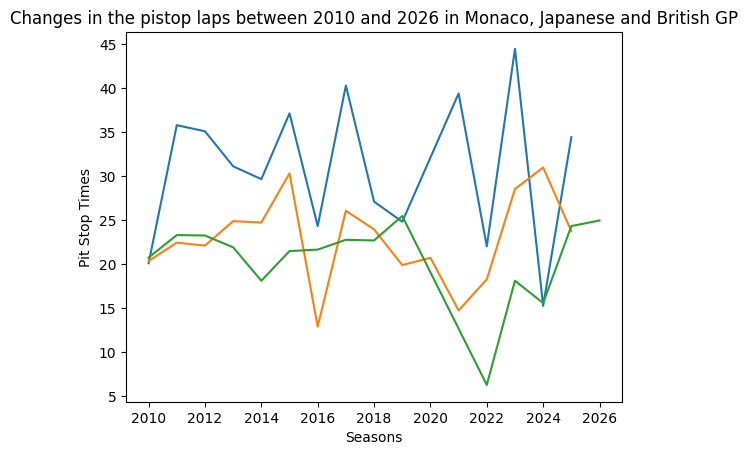

In [ ]:
plt.plot(monaco)
plt.plot(br)
plt.plot(jp)
plt.xlabel("Seasons")
plt.ylabel("Pit Stop Times")
plt.title("Changes in the pistop laps between 2010 and 2026 in Monaco, Japanese and British GP")

In [ ]:
hyp1

,raceId,year,round,circuitId,name,driverId,constructorId,positionOrder,laps,rank,statusId,stop,lap,duration,milliseconds
0,1166,2025,22,80,Las Vegas Grand Prix,830,9,1,50,1,1,1,25,21.708,0 days 00:00:00.000021708
1,1166,2025,22,80,Las Vegas Grand Prix,847,131,2,50,9,1,1,17,20.929,0 days 00:00:00.000020929
2,1166,2025,22,80,Las Vegas Grand Prix,863,131,3,50,2,1,1,2,21.968,0 days 00:00:00.000021968
3,1166,2025,22,80,Las Vegas Grand Prix,844,6,4,50,3,1,1,24,21.351,0 days 00:00:00.000021351
4,1166,2025,22,80,Las Vegas Grand Prix,832,3,5,50,4,1,1,22,21.164,0 days 00:00:00.000021164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12793,338,2010,2,1,Australian Grand Prix,10,166,15,41,15,22,1,9,28.501,0 days 00:00:00.000028501
12794,338,2010,2,1,Australian Grand Prix,810,166,16,26,17,9,1,10,27.693,0 days 00:00:00.000027693
12795,338,2010,2,1,Australian Grand Prix,810,166,16,26,17,9,2,25,15:47.885,0 days 00:00:00.000947885
12796,338,2010,2,1,Australian Grand Prix,20,9,17,25,13,36,1,9,24.527,0 days 00:00:00.000024527


In [ ]:
hyp1 = hyp1[hyp1['stop'] == 1]
hyp1

,raceId,year,round,circuitId,name,driverId,constructorId,positionOrder,laps,rank,statusId,stop,lap,duration,milliseconds
0,1166,2025,22,80,Las Vegas Grand Prix,830,9,1,50,1,1,1,25,21.708,0 days 00:00:00.000021708
1,1166,2025,22,80,Las Vegas Grand Prix,847,131,2,50,9,1,1,17,20.929,0 days 00:00:00.000020929
2,1166,2025,22,80,Las Vegas Grand Prix,863,131,3,50,2,1,1,2,21.968,0 days 00:00:00.000021968
3,1166,2025,22,80,Las Vegas Grand Prix,844,6,4,50,3,1,1,24,21.351,0 days 00:00:00.000021351
4,1166,2025,22,80,Las Vegas Grand Prix,832,3,5,50,4,1,1,22,21.164,0 days 00:00:00.000021164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12791,338,2010,2,1,Australian Grand Prix,812,164,14,53,16,15,1,8,27.526,0 days 00:00:00.000027526
12793,338,2010,2,1,Australian Grand Prix,10,166,15,41,15,22,1,9,28.501,0 days 00:00:00.000028501
12794,338,2010,2,1,Australian Grand Prix,810,166,16,26,17,9,1,10,27.693,0 days 00:00:00.000027693
12796,338,2010,2,1,Australian Grand Prix,20,9,17,25,13,36,1,9,24.527,0 days 00:00:00.000024527


In [ ]:
hyp1 = hyp1.drop(columns=['milliseconds'])
hyp1

,raceId,year,round,circuitId,name,driverId,constructorId,positionOrder,laps,rank,statusId,stop,lap,duration
0,1166,2025,22,80,Las Vegas Grand Prix,830,9,1,50,1,1,1,25,21.708
1,1166,2025,22,80,Las Vegas Grand Prix,847,131,2,50,9,1,1,17,20.929
2,1166,2025,22,80,Las Vegas Grand Prix,863,131,3,50,2,1,1,2,21.968
3,1166,2025,22,80,Las Vegas Grand Prix,844,6,4,50,3,1,1,24,21.351
4,1166,2025,22,80,Las Vegas Grand Prix,832,3,5,50,4,1,1,22,21.164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12791,338,2010,2,1,Australian Grand Prix,812,164,14,53,16,15,1,8,27.526
12793,338,2010,2,1,Australian Grand Prix,10,166,15,41,15,22,1,9,28.501
12794,338,2010,2,1,Australian Grand Prix,810,166,16,26,17,9,1,10,27.693
12796,338,2010,2,1,Australian Grand Prix,20,9,17,25,13,36,1,9,24.527


In [ ]:
hyp1.to_csv('/content/drive/MyDrive/DSA210/Hypothesis_Test1.csv')


**Hypothesis Test 2 - Data Merging - EDA**

---



In [ ]:
circuit_name = pd.read_csv('/content/drive/MyDrive/DSA210/F1 - Race Dataset/circuits.csv')
circuit_name.head(5)

,circuitId,circuitRef,name,location,country,lat,lng,alt,url
0,1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.84970,144.96800,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
1,2,sepang,Sepang International Circuit,Sepang,Malaysia,2.76083,101.73800,18,http://en.wikipedia.org/wiki/Sepang_Internatio...
2,3,bahrain,Bahrain International Circuit,Sakhir,Bahrain,26.03250,50.51060,7,http://en.wikipedia.org/wiki/Bahrain_Internati...
3,4,catalunya,Circuit de Barcelona-Catalunya,Montmeló,Spain,41.57000,2.26111,109,http://en.wikipedia.org/wiki/Circuit_de_Barcel...
4,5,istanbul,Istanbul Park,Istanbul,Turkey,40.95170,29.40500,130,http://en.wikipedia.org/wiki/Istanbul_Park


In [ ]:
circuit_name.drop(columns=['name', 'url'], inplace=True)
circuit_name.head(5)

,circuitId,circuitRef,location,country,lat,lng,alt
0,1,albert_park,Melbourne,Australia,-37.84970,144.96800,10
1,2,sepang,Sepang,Malaysia,2.76083,101.73800,18
2,3,bahrain,Sakhir,Bahrain,26.03250,50.51060,7
3,4,catalunya,Montmeló,Spain,41.57000,2.26111,109
4,5,istanbul,Istanbul,Turkey,40.95170,29.40500,130


In [ ]:
hyp2_race_data = races_data.drop(columns=['round', 'url', 'fp1_date', 'fp1_time', 'fp2_date', 'fp2_time', 'fp3_date', 'fp3_time', 'quali_date', 'quali_time', 'sprint_date', 'sprint_time'])
hyp2_race_data.head(5)

,raceId,year,circuitId,name,date,time
0,1182,2026,81,Spanish Grand Prix,2026-09-13,13:00:00
1,1188,2026,80,Las Vegas Grand Prix,2026-11-22,4:00:00
2,1166,2025,80,Las Vegas Grand Prix,2025-11-23,4:00:00
3,1142,2024,80,Las Vegas Grand Prix,2024-11-23,6:00:00
4,1119,2023,80,Las Vegas Grand Prix,2023-11-19,6:00:00


In [ ]:
merged_race_data = pd.merge(hyp2_race_data, circuit_name, on=['circuitId'], how='inner')
merged_race_data = merged_race_data[merged_race_data['year'] >= 2010]
merged_race_data.head(5)


,raceId,year,circuitId,name,date,time,circuitRef,location,country,lat,lng,alt
0,1182,2026,81,Spanish Grand Prix,2026-09-13,13:00:00,madring,Madrid,Spain,40.46528,-3.61528,667
1,1188,2026,80,Las Vegas Grand Prix,2026-11-22,4:00:00,vegas,Las Vegas,USA,36.11470,-115.17300,642
2,1166,2025,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.11470,-115.17300,642
3,1142,2024,80,Las Vegas Grand Prix,2024-11-23,6:00:00,vegas,Las Vegas,USA,36.11470,-115.17300,642
4,1119,2023,80,Las Vegas Grand Prix,2023-11-19,6:00:00,vegas,Las Vegas,USA,36.11470,-115.17300,642


In [ ]:
count = 0

merged_race_data['temp'] = -1.0

for index, row in merged_race_data.iterrows():
  date = row['date'].split('-')
  new_month = date[1]
  if(date[1][0] == '0'):
    new_month = date[1][1]
  date[1] = new_month

  time = row['time'].split(':')
  hour_start = int(time[0])
  hour_end = hour_start + 2
  start = datetime(int(date[0]), int(date[1]), int(date[2]))
  end = start
  POINT = ms.Point(int(row['lat']), int(row['lng']), int(row['alt']))
  stations = ms.stations.nearby(POINT, radius=200000, limit=4)
  station_id = stations.index[0]
  ts = ms.daily(station_id, start, end)
  df = ms.interpolate(ts, POINT).fetch()

  if(df is not None):
    if('temp' in df.columns):
      merged_race_data.loc[index, 'temp'] = df['temp'].iloc[0]
    elif('tmin' in df.columns and 'tmax' in df.columns):
      merged_race_data.loc[index, 'temp'] = (df['tmax'].iloc[0] + df['tmin'].iloc[0])/2
    elif('tmin' in df.columns):
      merged_race_data.loc[index, 'temp'] = df['tmin'].iloc[0]
    elif('tmax' in df.columns):
      merged_race_data.loc[index, 'temp'] = df['tmax'].iloc[0]

merged_race_data.head(5)

,raceId,year,circuitId,name,date,time,circuitRef,location,country,lat,lng,alt,temp
0,1182,2026,81,Spanish Grand Prix,2026-09-13,13:00:00,madring,Madrid,Spain,40.46528,-3.61528,667,-1.0
1,1188,2026,80,Las Vegas Grand Prix,2026-11-22,4:00:00,vegas,Las Vegas,USA,36.11470,-115.17300,642,-1.0
2,1166,2025,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.11470,-115.17300,642,13.7
3,1142,2024,80,Las Vegas Grand Prix,2024-11-23,6:00:00,vegas,Las Vegas,USA,36.11470,-115.17300,642,17.4
4,1119,2023,80,Las Vegas Grand Prix,2023-11-19,6:00:00,vegas,Las Vegas,USA,36.11470,-115.17300,642,15.6


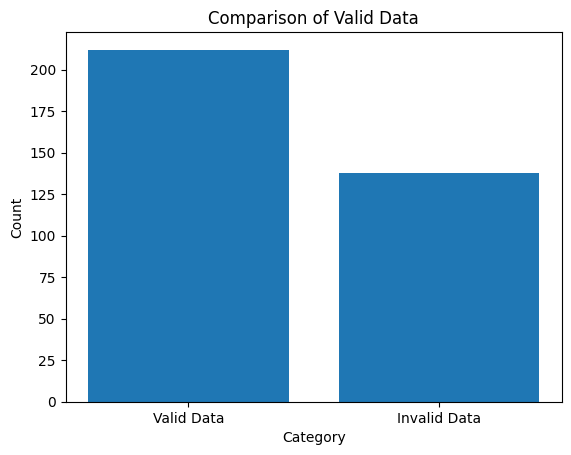

In [ ]:
invalid_data = (merged_race_data.temp == -1).sum()
valid_data = len(merged_race_data) - invalid_data

legend = ['Valid Data', 'Invalid Data']
vals = [valid_data, invalid_data]

plt.bar(legend, vals)
plt.title("Comparison of Valid Data")
plt.xlabel("Category")
plt.ylabel('Count')
plt.show()

In [ ]:
invalid = [-1.0]
invalid_races = merged_race_data[['name', 'temp']]
invalid_races = invalid_races[invalid_races['temp'].isin(invalid)]
invalid_races = invalid_races.groupby('name').size().sort_values()
invalid_races

name
70th Anniversary Grand Prix     1
Barcelona Grand Prix            1
Dutch Grand Prix                1
Eifel Grand Prix                1
European Grand Prix             1
Hungarian Grand Prix            1
Japanese Grand Prix             1
Indian Grand Prix               1
Qatar Grand Prix                1
Singapore Grand Prix            1
Spanish Grand Prix              1
Miami Grand Prix                1
Mexico City Grand Prix          1
Las Vegas Grand Prix            1
Australian Grand Prix           2
French Grand Prix               2
United States Grand Prix        2
Styrian Grand Prix              2
German Grand Prix               2
Mexican Grand Prix              5
Azerbaijan Grand Prix           8
Brazilian Grand Prix            8
Monaco Grand Prix              11
Abu Dhabi Grand Prix           12
British Grand Prix             12
Italian Grand Prix             13
Austrian Grand Prix            13
Canadian Grand Prix            15
Belgian Grand Prix             17
dtype: in

Text(0, 0.5, 'Counts')

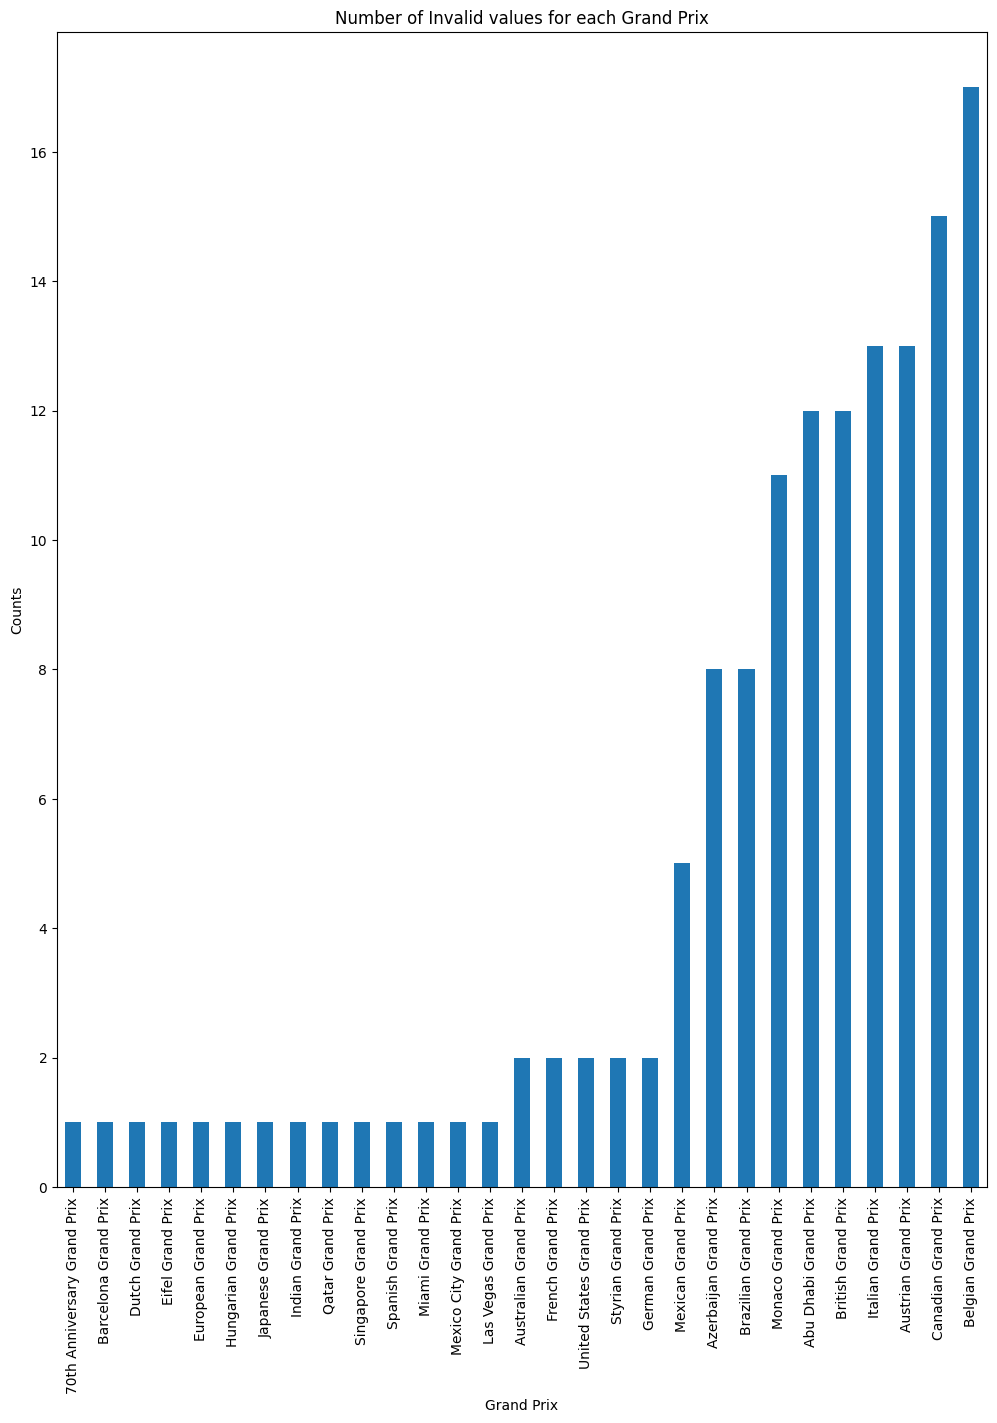

In [ ]:
fig, ax = plt.subplots(figsize=(12, 15))
invalid_races.plot(kind='bar', ax=ax)
ax.set_title('Number of Invalid values for each Grand Prix')
ax.set_xlabel('Grand Prix')
ax.set_ylabel('Counts')


In [ ]:
merged_race_data1 = merged_race_data[merged_race_data['temp'] > -1]
merged_race_data1.head(5)

,raceId,year,circuitId,name,date,time,circuitRef,location,country,lat,lng,alt,temp
2,1166,2025,80,Las Vegas Grand Prix,2025-11-23,4:00:00,vegas,Las Vegas,USA,36.1147,-115.1730,642,13.7
3,1142,2024,80,Las Vegas Grand Prix,2024-11-23,6:00:00,vegas,Las Vegas,USA,36.1147,-115.1730,642,17.4
4,1119,2023,80,Las Vegas Grand Prix,2023-11-19,6:00:00,vegas,Las Vegas,USA,36.1147,-115.1730,642,15.6
6,1150,2025,79,Miami Grand Prix,2025-05-04,20:00:00,miami,Miami Gardens,USA,25.9581,-80.2389,0,25.2
7,1126,2024,79,Miami Grand Prix,2024-05-05,20:00:00,miami,Miami Gardens,USA,25.9581,-80.2389,0,26.6


In [ ]:
pitstop_data.head(10)

,raceId,driverId,stop,lap,duration,milliseconds
0,258,100,1,1,49.111,49111
1,258,79,1,17,28.482,28482
2,258,57,1,18,43.745,43745
3,258,71,1,18,21.992,21992
4,258,105,1,19,27.693,27693
5,258,91,1,19,24.806,24806
6,258,44,1,18,53.89,53890
7,258,94,1,22,34.437,34437
8,258,30,1,23,23.342,23342
9,258,104,1,23,56.753,56753


In [ ]:
stop_count = pitstop_data.groupby(['raceId'])['stop'].mean()
stop_count

raceId
1       1.666667
2       2.000000
3       1.483871
4       1.571429
5       1.718750
          ...   
1167    1.609756
1168    1.259259
1169    1.531250
1170    1.105263
1171    1.586207
Name: stop, Length: 600, dtype: float64

In [ ]:
hyp2_final = pd.merge(stop_count, merged_race_data1, on=['raceId'], how='inner')
hyp2_final

,raceId,stop,year,circuitId,name,date,time,circuitRef,location,country,lat,lng,alt,temp
0,337,1.095238,2010,3,Bahrain Grand Prix,2010-03-14,12:00:00,bahrain,Sakhir,Bahrain,26.03250,50.51060,7,26.10
1,338,1.428571,2010,1,Australian Grand Prix,2010-03-28,6:00:00,albert_park,Melbourne,Australia,-37.84970,144.96800,10,20.65
2,339,1.150000,2010,2,Malaysian Grand Prix,2010-04-04,8:00:00,sepang,Sepang,Malaysia,2.76083,101.73800,18,29.90
3,340,2.567164,2010,17,Chinese Grand Prix,2010-04-18,6:00:00,shanghai,Shanghai,China,31.33890,121.22000,5,16.90
4,341,1.250000,2010,4,Spanish Grand Prix,2010-05-09,12:00:00,catalunya,Montmeló,Spain,41.57000,2.26111,109,15.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
207,1167,1.609756,2025,78,Qatar Grand Prix,2025-11-30,16:00:00,losail,Lusail,Qatar,25.49000,51.45420,12,21.70
208,1168,1.259259,2025,24,Abu Dhabi Grand Prix,2025-12-07,13:00:00,yas_marina,Abu Dhabi,UAE,24.46720,54.60310,3,23.20
209,1169,1.531250,2026,1,Australian Grand Prix,2026-03-08,4:00:00,albert_park,Melbourne,Australia,-37.84970,144.96800,10,19.30
210,1170,1.105263,2026,17,Chinese Grand Prix,2026-03-15,7:00:00,shanghai,Shanghai,China,31.33890,121.22000,5,12.90


In [ ]:
hyp2_final.to_csv('/content/drive/MyDrive/DSA210/Hypothesis_Test2.csv')
